# Calibrate Pretraining

I expect pretraining the preference ranking MLP on naturalness should do _something_ but currently (4/20/25) seeing no difference at all. Let's do some debugging / tuning (epochs, learning rate, batch size, etc).

In [28]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import seaborn as sns

# Configure logging
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

from folde.data import get_available_proteingym_datasets, get_proteingym_dataset
from folde.campaign import simulate_campaign, simulate_campaigns
from folde.types import FolDEModelConfig, ModelEvaluation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
available_datasets = get_available_proteingym_datasets('300m_extras', '600m')
assert not available_datasets.empty
available_datasets.head(10)

2025-05-17 06:40:42,623 - folde.data - INFO - Loaded metadata for 217 DMS datasets
2025-05-17 06:40:42,767 - folde.data - INFO - Found 9 datasets with embedding model '300m_extras' and naturalness model '600m'


,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type
15,ANCSZ_Hobbs_2022,ANCSZ_Hobbs_2022.csv,ANCSZ,Eukaryote,Reconstructed ancestor,MADSANHLPYFYGSITREEAEDYLKQGGMSDGLFLLRQSLNSLGGY...,627,False,4670,4670,...,ANCSZ_Hobbs_2022.csv,DMS_value,1,mutant,ANCSZ_theta_0.2.npy,ANCSZ.pdb,1-627,1.0,NaN,Activity
21,BLAT_ECOLX_Firnberg_2014,BLAT_ECOLX_Firnberg_2014.csv,BLAT_ECOLX,Prokaryote,Escherichia coli,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,286,False,4783,4783,...,BLAT_ECOLX_Firnberg_2014.csv,linear,1,mutant,BLAT_ECOLX_theta_0.2.npy,BLAT_ECOLX.pdb,1-286,0.1,NaN,OrganismalFitness
36,CBS_HUMAN_Sun_2020,CBS_HUMAN_Sun_2020.csv,CBS_HUMAN,Human,Homo sapiens,MPSETPQAEVGPTGCPHRSGPHSAKGSLEKGSPEDKEAKEPLWIRP...,551,False,7217,7217,...,NaN,score,1,mutant,CBS_HUMAN_theta0.2_2023-10-12_b08.npy,CBS_HUMAN.pdb,1-551,1.0,NaN,OrganismalFitness
72,HEM3_HUMAN_Loggerenberg_2023,HEM3_HUMAN_Loggerenberg_2023.csv,HEM3_HUMAN,Human,Homo sapiens,MSGNGNAAATAEENSPKMRVIRVGTRKSQLARIQTDSVVATLKASY...,361,False,5689,5689,...,NaN,score,1,mutant,HEM3_HUMAN_theta0.2_2023-08-07_b02.npy,HEM3_HUMAN.pdb,1-361,1.0,NaN,Activity
76,HSP82_YEAST_Flynn_2019,HSP82_YEAST_Flynn_2019.csv,HSP82_YEAST,Eukaryote,Saccharomyces cerevisiae,MASETFEFQAEITQLMSLIINTVYSNKEIFLRELISNASDALDKIR...,709,False,13294,13294,...,HSP82_YEAST_Flynn_2019.csv,s (37°C),1,mutant,HSP82_YEAST_theta_0.2.npy,HSP82_YEAST.pdb,1-709,1.0,NaN,OrganismalFitness
78,HXK4_HUMAN_Gersing_2022_activity,HXK4_HUMAN_Gersing_2022_activity.csv,HXK4_HUMAN,Human,Homo sapiens,MLDDRARMEAAKKEKVEQILAEFQLQEEDLKKVMRRMQKEMDRGLR...,465,False,8570,8570,...,HXK4_HUMAN_Gersing_2022.csv,score,1,mutant,HXK4_HUMAN_theta_0.2.npy,HXK4_HUMAN.pdb,1-465,1.0,NaN,OrganismalFitness
114,OXDA_RHOTO_Vanella_2023_activity,OXDA_RHOTO_Vanella_2023_activity.csv,OXDA_RHOTO,Eukaryote,Rhodotorula gracilis,HSQKRVVVLGSGVIGLSSALILARKGYSVHILARDLPEDVSSQTFA...,364,False,6396,6396,...,Figure_2.xlsx,activity fitness,1,mutant,OXDA_RHOTO_theta0.2_2023-08-07_b02.npy,OXDA_RHOTO.pdb,1-364,1.0,NaN,Activity
133,PPM1D_HUMAN_Miller_2022,PPM1D_HUMAN_Miller_2022.csv,PPM1D_HUMAN,Human,Homo sapiens,MAGLYSLGVSVFSDQGGRKYMEDVTQIVVEPEPTAEEKPSPRRSLS...,605,False,7889,7889,...,PPM1D_HUMAN_Miller_2022_raw.xlsx,fitness,1,mutant,PPM1D_HUMAN_theta0.2_2023-10-12_b01.npy,PPM1D_HUMAN.pdb,1-605,1.0,NaN,OrganismalFitness
178,SHOC2_HUMAN_Kwon_2022,SHOC2_HUMAN_Kwon_2022.csv,SHOC2_HUMAN,Human,Homo sapiens,MSSSLGKEKDSKEKDPKVPSAKEREKEAKASGGFGKESKEKEPKTK...,582,False,10972,10972,...,2022.3.16.Extended Data Table 4.csv,LFC_scaled,1,variant.by.aa,SHOC2_HUMAN_theta0.2_2023-10-12_b04.npy,SHOC2_HUMAN.pdb,1-582,1.0,NaN,OrganismalFitness


In [30]:
naturalness_df, embedding_df, activity_df = get_proteingym_dataset(
    'HSP82_YEAST_Flynn_2019',  # Chosen because naturalness has decent predictive power.
    '300m_extras',
    '600m',
)

2025-05-17 06:40:44,742 - folde.data - INFO - Loaded activity data for HSP82_YEAST_Flynn_2019 with 13294 rows
2025-05-17 06:41:16,589 - folde.data - INFO - Loaded embeddings for HSP82_YEAST_Flynn_2019 with 13472 rows
2025-05-17 06:41:16,702 - folde.data - INFO - Loaded naturalness scores for HSP82_YEAST_Flynn_2019 with 23397 rows


In [4]:
# naturalness_df2, embedding_df2, activity_df2 = get_proteingym_dataset(
#     'SHOC2_HUMAN_Kwon_2022',  # Chosen because naturalness has decent predictive power.
#     '300m_extras',
#     '600m',
# )

In [5]:
# naturalness_df3, embedding_df3, activity_df3 = get_proteingym_dataset(
#     'PPM1D_HUMAN_Miller_2022',  # Chosen because naturalness has decent predictive power.
#     '300m_extras',
#     '600m',
# )

In [6]:
naturalness_df = naturalness_df.sort_values(by='wt_marginal')
naturalness_df['wtm_index'] = [v/float(len(naturalness_df)) for v in np.arange(len(naturalness_df))]
# naturalness_df2 = naturalness_df2.sort_values(by='wt_marginal')
# naturalness_df2['wtm_index'] = [v/float(len(naturalness_df2)) for v in np.arange(len(naturalness_df2))]
# naturalness_df3 = naturalness_df3.sort_values(by='wt_marginal')
# naturalness_df3['wtm_index'] = [v/float(len(naturalness_df3)) for v in np.arange(len(naturalness_df3))]


In [7]:
# from matplotlib import pyplot as plt
# import seaborn as sns

# sns.scatterplot(data=naturalness_df.sort_values(by='wt_marginal'), x='wtm_index', y='wt_marginal', label='HSP82')
# sns.scatterplot(data=naturalness_df2.sort_values(by='wt_marginal'), x='wtm_index', y='wt_marginal', label='SHOC2')
# sns.scatterplot(data=naturalness_df3.sort_values(by='wt_marginal'), x='wtm_index', y='wt_marginal', label='PPM1D')
# plt.yscale('log')
# plt.axhline(y=1.0, color='black', linewidth=0.5)

In [8]:
naturalness_df.sort_values('wt_marginal', ascending=False)

,seq_id,probability,locus,wt_probability,wt_marginal,wtm_index
seq_id,,,,,,
L127A,L127A,8.828125e-01,127,0.000055,1.609906e+04,0.999925
L127S,L127S,7.275391e-02,127,0.000055,1.326748e+03,0.999850
R579V,R579V,6.757812e-01,579,0.000580,1.165474e+03,0.999774
S411K,S411K,9.843750e-01,411,0.001152,8.544636e+02,0.999699
Y305A,Y305A,7.734375e-01,305,0.001030,7.509333e+02,0.999624
...,...,...,...,...,...,...
T101W,T101W,2.735760e-09,101,0.996094,2.746489e-09,0.000301
L108D,L108D,2.459274e-09,108,0.957031,2.569690e-09,0.000226
E149P,E149P,2.080924e-09,149,0.996094,2.089084e-09,0.000150


In [27]:
naturalness_df.sort_values('wt_marginal', ascending=False).iloc[:16]

,seq_id,probability,locus,wt_probability,wt_marginal,wtm_index
seq_id,,,,,,
L127A,L127A,0.882812,127,0.000055,16099.060870,0.999925
L127S,L127S,0.072754,127,0.000055,1326.747826,0.999850
R579V,R579V,0.675781,579,0.000580,1165.473684,0.999774
S411K,S411K,0.984375,411,0.001152,854.463576,0.999699
Y305A,Y305A,0.773438,305,0.001030,750.933333,0.999624
Q72E,Q72E,0.921875,72,0.001572,586.563107,0.999549
L378I,L378I,0.878906,378,0.002319,378.947368,0.999473
L127G,L127G,0.020752,127,0.000055,378.434783,0.999398
Q55V,Q55V,0.632812,55,0.002426,260.830189,0.999323


In [10]:
import numpy as np
# Measure 16 activities.
all_seq_ids = activity_df.index.unique()
# measured_seq_ids = np.random.choice(all_seq_ids, size=16, replace=False)
measured_seq_ids = naturalness_df.sort_values('wt_marginal', ascending=False).iloc[:16].index
validation_seq_ids = np.random.choice([a for a in all_seq_ids if a not in measured_seq_ids], size=100, replace=False)

In [14]:
entire_naturalness_series

seq_id
I117W    1.746230e-09
I19W     1.957604e-09
E149P    2.089084e-09
L108D    2.569690e-09
T101W    2.746489e-09
             ...     
Y305A    7.509333e+02
S411K    8.544636e+02
R579V    1.165474e+03
L127S    1.326748e+03
L127A    1.609906e+04
Name: wt_marginal, Length: 13294, dtype: float64

In [13]:
# entire_naturalness_series
entire_embedding_series

seq_id
S282Q    [0.0032465176191180944, -0.009529565460979939,...
K394Y    [0.00359448604285717, -0.009587935172021389, 0...
K234R    [0.0032261000014841557, -0.00928778201341629, ...
I20F     [0.003695323597639799, -0.009733744896948338, ...
L185Y    [0.0036440871190279722, -0.009881140664219856,...
                               ...                        
T684W    [0.00332773569971323, -0.009654340334236622, 0...
E517K    [0.0035706704948097467, -0.009675419889390469,...
S447M    [0.0031825064215809107, -0.010180135257542133,...
E529I    [0.003384821116924286, -0.009742838330566883, ...
L439W    [0.0031831394881010056, -0.00962131004780531, ...
Name: embedding, Length: 13294, dtype: object

In [19]:
from folde.few_shot_models import TorchMLPFewShotModel

# Get few-shot model
pretrain_few_shot_model = TorchMLPFewShotModel(
    pretrain=True,
    pretrain_epochs=50,
    embedding_dim=960,
    hidden_dims=[100, 50],
    dropout=0.2,  # I don't know if this is important.
    learning_rate=1e-3,   # I MADE THIS HIGHER BECAUSE THE DEFAULT WASN'T LEARNING
    weight_decay=1e-5,
    random_state=5,
    train_epochs=500,
    train_patience=500
)
nopretrain_few_shot_model = TorchMLPFewShotModel(
    pretrain=False,
    pretrain_epochs=50,
    embedding_dim=960,
    hidden_dims=[100, 50],
    dropout=0.2,  # I don't know if this is important.
    learning_rate=1e-3,   # I MADE THIS HIGHER BECAUSE THE DEFAULT WASN'T LEARNING
    weight_decay=1e-5,
    random_state=5,
    train_epochs=500,
    train_patience=500
)

predicted_activity_series_list = []

for few_shot_model in [pretrain_few_shot_model, nopretrain_few_shot_model]:
    # Convert list of embeddings to numpy array
    entire_naturalness_series = naturalness_df.wt_marginal
    entire_embedding_series = embedding_df.embedding[entire_naturalness_series.index]
    train_activity_series = activity_df.loc[measured_seq_ids].DMS_score
    validation_activity_series = activity_df.loc[validation_seq_ids].DMS_score

    few_shot_model.fit(
        entire_naturalness_series,
        entire_embedding_series,
        train_activity_series,
        validation_activity_series,
    )

    # Use the get_top_n method from FewShotModel
    top_seq_ids, predicted_activity_series = few_shot_model.get_top_n(
        16,
        entire_naturalness_series,
        entire_embedding_series,
    )
    predicted_activity_series_list.append(predicted_activity_series)

2025-05-17 01:53:36,804 - root - INFO - Pretraining model with naturalness data with 13294 single mutants.
2025-05-17 01:57:01,152 - root - INFO - Pretrain improvement: train loss (0.4043 -> 0.2386) val loss (0.4341 -> 0.3354)
2025-05-17 01:57:04,419 - root - INFO - Finetune improvement: train loss (2.3223 -> 0.0409) val loss (1.1982 -> 1.8063)
2025-05-17 01:57:07,969 - app.helpers.preference_ranking - INFO - Early stopping at epoch 500
2025-05-17 01:57:07,973 - root - INFO - Finetune improvement: train loss (0.7225 -> 0.0277) val loss (0.6931 -> 4.0177)


In [23]:
loss_df = pd.concat([
    pd.DataFrame({
        'model': 'no_pretrain',
        'loss': 'train',
        'value': nopretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['train_loss'],
        'epoch': range(len(nopretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['train_loss']))
    }),
    pd.DataFrame({
        'model': 'no_pretrain',
        'loss': 'val',
        'value': nopretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['val_loss'],
        'epoch': range(len(nopretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['val_loss']))
    }),
    pd.DataFrame({
        'model': 'pretrain',
        'loss': 'train',
        'value': (
            pretrain_few_shot_model.get_debug_info()['pretrain_metrics'][0]['train_loss'] + 
            pretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['train_loss']
        ),
        'epoch': range(
            -len(pretrain_few_shot_model.get_debug_info()['pretrain_metrics'][0]['train_loss']),
            len(pretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['train_loss'])
        )
    }),
    pd.DataFrame({
        'model': 'pretrain',
        'loss': 'val',
        'value': (
            pretrain_few_shot_model.get_debug_info()['pretrain_metrics'][0]['val_loss'] + 
            pretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['val_loss']
        ),
        'epoch': range(
            -len(pretrain_few_shot_model.get_debug_info()['pretrain_metrics'][0]['val_loss']),
            len(pretrain_few_shot_model.get_debug_info()['finetune_metrics'][0]['val_loss'])
        )
    })
], ignore_index=True)
loss_df['category'] = loss_df['model'] + '_' + loss_df['loss']

In [24]:
loss_df

,model,loss,value,epoch,category
0,no_pretrain,train,0.722549,0,no_pretrain_train
1,no_pretrain,train,0.463610,1,no_pretrain_train
2,no_pretrain,train,0.386488,2,no_pretrain_train
3,no_pretrain,train,0.362909,3,no_pretrain_train
4,no_pretrain,train,0.380991,4,no_pretrain_train
...,...,...,...,...,...
2095,pretrain,val,NaN,495,pretrain_val
2096,pretrain,val,NaN,496,pretrain_val
2097,pretrain,val,NaN,497,pretrain_val
2098,pretrain,val,NaN,498,pretrain_val


(-10.0, 10.0)

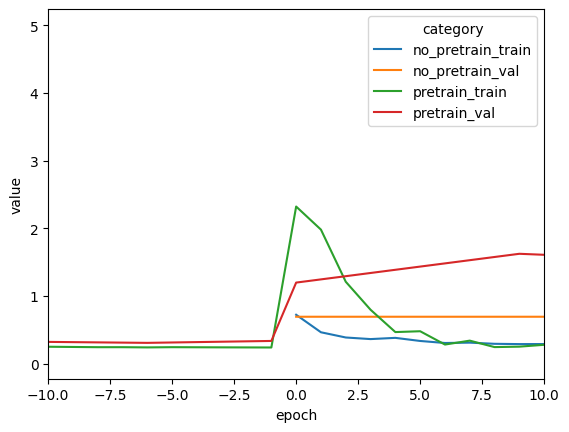

In [26]:
import seaborn as sns
sns.lineplot(data=loss_df, x='epoch', y='value', hue='category')
plt.xlim(-10, 10)

In [115]:
from scipy.stats import spearmanr

for lst in predicted_activity_series_list:
  print(spearmanr(lst[0], activity_df.DMS_score))


SignificanceResult(statistic=0.2704394346785104, pvalue=1.5539995575464568e-221)
SignificanceResult(statistic=-0.21561928837307243, pvalue=1.2483293719986463e-139)


<Axes: xlabel='None', ylabel='DMS_score'>

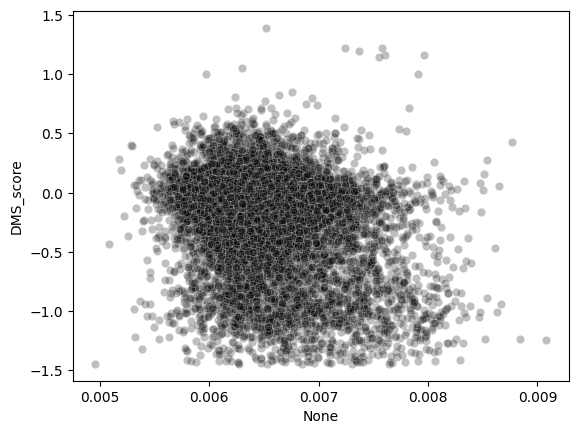

In [111]:
import seaborn as sns

sns.scatterplot(x=predicted_activity_series_list[1][0], y=activity_df.DMS_score, alpha=0.25, color='black')
# predicted_activity_series_list[0][0]

In [35]:
6782*2

13564

In [34]:
predicted_activity_series_list[0][0][predicted_activity_series_list[0][0].duplicated()]

seq_id
Y305A    1.614573
S602G    1.614573
Y289L    1.614573
K235Q    1.614573
E683W    1.614573
           ...   
F421V    1.614573
I524M    1.614573
G633D    1.614573
D534S    1.614573
I388A    1.614573
Length: 6782, dtype: float32